In [2]:
import pandas as pd

users = pd.DataFrame({
    'user_id': [1,2,3,4,5,6,7],
    'signup_date': [
        '2024-01-05','2024-01-10',
        '2024-02-01','2024-02-15',
        '2024-03-01','2024-03-10',
        '2024-04-01'
    ]
})

users['signup_date'] = pd.to_datetime(users['signup_date'])
users['cohort_month'] = users['signup_date'].dt.to_period('M')


transactions = pd.DataFrame({
    'user_id': [1,1,2,3,4,4,5,6],
    'transaction_date': [
        '2024-01-06',
        '2024-03-10',  # delayed payment
        '2024-02-15',
        '2024-02-10',
        '2024-03-10',
        '2024-05-10',  # long gap
        '2024-03-15',
        '2024-04-20'
    ],
    'revenue': [100, 200, 150, 120, 300, 100, 200, 250]
})

transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
transactions['transaction_month'] = transactions['transaction_date'].dt.to_period('M')

In [3]:
data = transactions.merge(users, on='user_id', how='left')
data

,user_id,transaction_date,revenue,transaction_month,signup_date,cohort_month
0,1,2024-01-06,100,2024-01,2024-01-05,2024-01
1,1,2024-03-10,200,2024-03,2024-01-05,2024-01
2,2,2024-02-15,150,2024-02,2024-01-10,2024-01
3,3,2024-02-10,120,2024-02,2024-02-01,2024-02
4,4,2024-03-10,300,2024-03,2024-02-15,2024-02
5,4,2024-05-10,100,2024-05,2024-02-15,2024-02
6,5,2024-03-15,200,2024-03,2024-03-01,2024-03
7,6,2024-04-20,250,2024-04,2024-03-10,2024-03


In [4]:
data['cohort_index'] = (data['transaction_month'] - data['cohort_month']).apply(lambda x: x.n)
data

,user_id,transaction_date,revenue,transaction_month,signup_date,cohort_month,cohort_index
0,1,2024-01-06,100,2024-01,2024-01-05,2024-01,0
1,1,2024-03-10,200,2024-03,2024-01-05,2024-01,2
2,2,2024-02-15,150,2024-02,2024-01-10,2024-01,1
3,3,2024-02-10,120,2024-02,2024-02-01,2024-02,0
4,4,2024-03-10,300,2024-03,2024-02-15,2024-02,1
5,4,2024-05-10,100,2024-05,2024-02-15,2024-02,3
6,5,2024-03-15,200,2024-03,2024-03-01,2024-03,0
7,6,2024-04-20,250,2024-04,2024-03-10,2024-03,1


In [5]:
cohort_data = data.groupby(['cohort_month', 'cohort_index'])['revenue'].sum().reset_index()
cohort_data

,cohort_month,cohort_index,revenue
0,2024-01,0,100
1,2024-01,1,150
2,2024-01,2,200
3,2024-02,0,120
4,2024-02,1,300
5,2024-02,3,100
6,2024-03,0,200
7,2024-03,1,250


In [6]:
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='revenue').fillna(0)
cohort_pivot

cohort_index,0,1,2,3
cohort_month,,,,
2024-01,100.0,150.0,200.0,0.0
2024-02,120.0,300.0,0.0,100.0
2024-03,200.0,250.0,0.0,0.0


In [7]:
cohort_pivot = cohort_pivot.reindex(users['cohort_month'].unique(), fill_value=0)

In [8]:
cohort_pivot = cohort_pivot.reindex(
    columns=range(cohort_pivot.columns.max()+1),
    fill_value=0
) 
cohort_pivot


cohort_index,0,1,2,3
cohort_month,,,,
2024-01,100.0,150.0,200.0,0.0
2024-02,120.0,300.0,0.0,100.0
2024-03,200.0,250.0,0.0,0.0
2024-04,0.0,0.0,0.0,0.0


In [9]:
total_users = users.groupby('cohort_month')['user_id'].nunique()

In [10]:
ltv = cohort_pivot.div(total_users, axis=0)
ltv

cohort_index,0,1,2,3
cohort_month,,,,
2024-01,50.0,75.0,100.0,0.0
2024-02,60.0,150.0,0.0,50.0
2024-03,100.0,125.0,0.0,0.0
2024-04,0.0,0.0,0.0,0.0


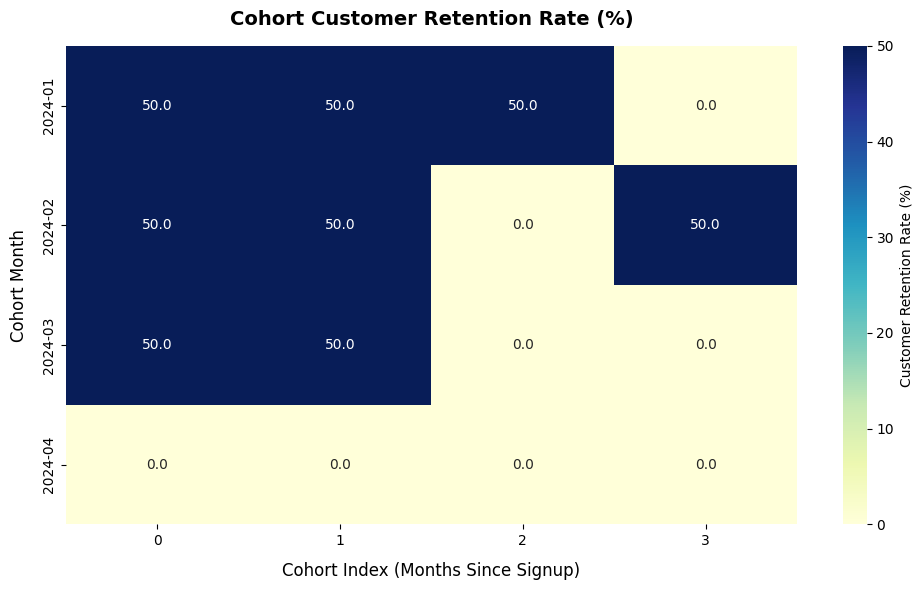

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# DATA PREPARATION FOR VISUALS
# ==============================================================================


retention_data = data.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
retention_pivot = retention_data.pivot(index='cohort_month', columns='cohort_index', values='user_id').fillna(0)


retention_pivot = retention_pivot.reindex(users['cohort_month'].unique(), fill_value=0)
retention_pivot = retention_pivot.reindex(columns=range(int(cohort_pivot.columns.max()) + 1), fill_value=0)


retention_pct = retention_pivot.div(total_users, axis=0) * 100


# ==============================================================================
# VISUAL 1: COHORT RETENTION HEATMAP
# ==============================================================================
plt.figure(figsize=(10, 6))

heatmap_labels = [str(month) for month in retention_pct.index]

sns.heatmap(
    data=retention_pct, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Customer Retention Rate (%)'},
    yticklabels=heatmap_labels
)

plt.title('Cohort Customer Retention Rate (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cohort Index (Months Since Signup)', fontsize=12, labelpad=10)
plt.ylabel('Cohort Month', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()




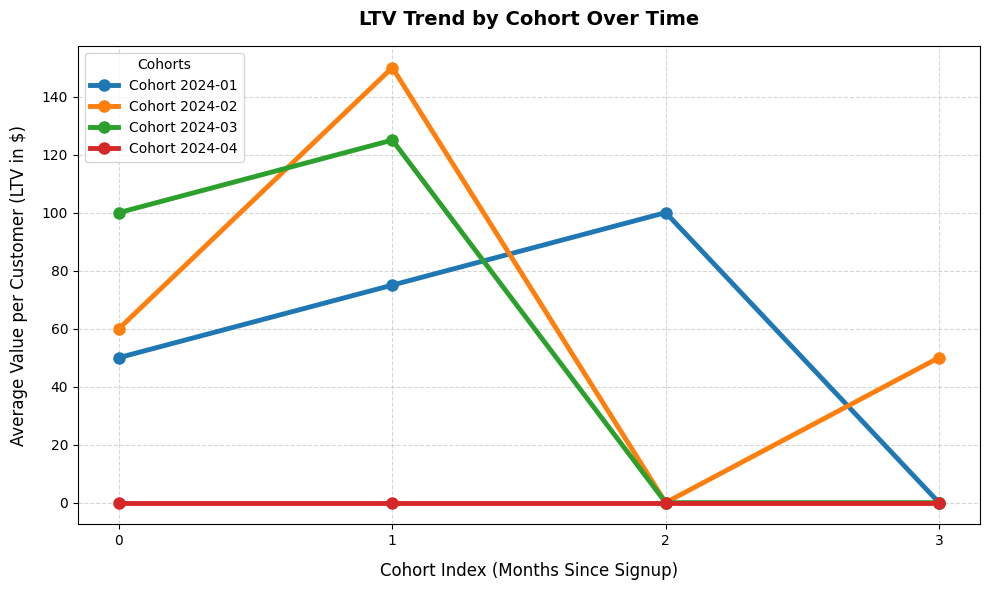

In [12]:
# ==============================================================================
# VISUAL 2: LTV TREND BY COHORT
# ==============================================================================
plt.figure(figsize=(10, 6))

# Plot a line for each cohort month with mobile-optimized thickness and markers
for cohort in ltv.index:
    cohort_series = ltv.loc[cohort]
    
    plt.plot(
        cohort_series.index, 
        cohort_series.values, 
        marker='o', 
        linewidth=3.5,     # Increased thickness for mobile screens
        markersize=8,      # Increased marker size for clear readability
        label=f'Cohort {str(cohort)}'
    )

plt.title('LTV Trend by Cohort Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cohort Index (Months Since Signup)', fontsize=12, labelpad=10)
plt.ylabel('Average Value per Customer (LTV in $)', fontsize=12, labelpad=10)
plt.xticks(range(int(ltv.columns.max()) + 1))
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title="Cohorts", loc='upper left')
plt.tight_layout()
plt.show()
